# 🔬 BreastGuard AI — CNN + SVM Hybrid Model Training
**Dataset**: BreakHis (Breast Cancer Histopathological Image Database)  
**Architecture**: EfficientNetB0 (ImageNet pre-trained) → 256-D feature vector → SVM (RBF)  
**Target accuracy**: ≥ 90%  
**Output files** (copy these to your Flask `app/ml/saved_models/` folder):
- `cnn_feature_extractor.keras`
- `svm_classifier.joblib`
- `feature_scaler.joblib`

---
### 📋 Steps
1. Mount Google Drive & set paths
2. **Extract `breakhis.zip` → Colab local disk**
3. Install / verify packages
4. Explore & visualise the dataset
5. Build data pipelines (augmentation)
6. Phase 1 — train CNN classifier (frozen EfficientNetB0)
7. Phase 2 — fine-tune top layers
8. Phase 3 — extract features → train SVM
9. Evaluate (accuracy, AUC, confusion matrix, classification report)
10. Save models + copy to Drive

## 1 · Mount Google Drive & Set Paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ─────────────────────────────────────────────────────────────────────
# 🔧  Set the path to breakhis.zip on your Google Drive.
#     The zip should contain the folder structure:
#
#   breakhis.zip
#   └── BreaKHis_v1/
#       ├── Folds.csv
#       └── BreaKHis_v1/
#           └── histology_slides/
#               └── breast/
#                   ├── benign/
#                   │   └── SOB/
#                   │       ├── adenosis/
#                   │       ├── fibroadenoma/
#                   │       ├── phyllodes_tumor/
#                   │       └── tubular_adenoma/
#                   └── malignant/
#                       └── SOB/
#                           ├── ductal_carcinoma/
#                           ├── lobular_carcinoma/
#                           ├── mucinous_carcinoma/
#                           └── papillary_carcinoma/
# ─────────────────────────────────────────────────────────────────────
ZIP_PATH = '/content/drive/MyDrive/BreakHis.zip'   # ← update if stored in a subfolder

# Output: trained models saved here (persists after runtime ends)
DRIVE_MODEL_OUTPUT = '/content/drive/MyDrive/BreastGuard_Models'
LOCAL_MODEL_OUTPUT = '/content/saved_models'

os.makedirs(DRIVE_MODEL_OUTPUT, exist_ok=True)
os.makedirs(LOCAL_MODEL_OUTPUT, exist_ok=True)

print('Drive mounted.')
print('ZIP path     :', ZIP_PATH)
print('ZIP exists?  :', os.path.exists(ZIP_PATH))
print('Model output :', DRIVE_MODEL_OUTPUT)


Mounted at /content/drive
Drive mounted.
ZIP path     : /content/drive/MyDrive/BreakHis.zip
ZIP exists?  : True
Model output : /content/drive/MyDrive/BreastGuard_Models


## 2 · Extract `breakhis.zip` Dataset

In [2]:
import os, zipfile, time

# ─────────────────────────────────────────────────────────────────────
# 🔧  EDIT: path to breakhis.zip on your Google Drive
# ─────────────────────────────────────────────────────────────────────
ZIP_PATH   = '/content/drive/MyDrive/BreakHis.zip'   # ← change if stored elsewhere
EXTRACT_TO = '/content/breakhis'                      # local Colab disk (faster I/O)

# Expected path after extraction (relative to EXTRACT_TO)
# zip contains:  BreaKHis_v1/BreaKHis_v1/histology_slides/breast/...
EXTRACTED_BREAST_PATH = os.path.join(
    EXTRACT_TO, 'BreaKHis_v1', 'BreaKHis_v1', 'histology_slides', 'breast'
)

# ── Skip extraction if already done (re-run safe) ────────────────────
if os.path.exists(EXTRACTED_BREAST_PATH):
    print('✅ Dataset already extracted — skipping unzip.')
    print('   Path:', EXTRACTED_BREAST_PATH)
else:
    if not os.path.exists(ZIP_PATH):
        raise FileNotFoundError(
            f'❌  breakhis.zip not found at: {ZIP_PATH}\n'
            f'    Upload it to Google Drive and update ZIP_PATH above.'
        )

    os.makedirs(EXTRACT_TO, exist_ok=True)
    print(f'📦  Extracting {ZIP_PATH}')
    print(f'    → {EXTRACT_TO}')
    print('    (this takes ~1–3 min for the full BreakHis dataset)')

    t0 = time.time()
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        total = len(zf.namelist())
        zf.extractall(EXTRACT_TO)
    elapsed = time.time() - t0

    print(f'\n✅  Extraction complete in {elapsed:.1f}s')
    print(f'    Files extracted : {total:,}')
    print(f'    Destination     : {EXTRACT_TO}')

# ── Override DRIVE_DATASET_PATH to use the faster local copy ─────────
DRIVE_DATASET_PATH = EXTRACTED_BREAST_PATH
FOLDS_CSV          = os.path.join(EXTRACT_TO, 'BreaKHis_v1', 'Folds.csv')

print()
print('Using local dataset path:', DRIVE_DATASET_PATH)
print('Folds.csv               :', FOLDS_CSV)
print('Path exists?            ', os.path.exists(DRIVE_DATASET_PATH))

# Quick sanity: count benign / malignant top-level folders
for cls in ['benign', 'malignant']:
    cls_path = os.path.join(DRIVE_DATASET_PATH, cls)
    if os.path.exists(cls_path):
        subtypes = [d for d in os.listdir(os.path.join(cls_path, 'SOB'))
                    if os.path.isdir(os.path.join(cls_path, 'SOB', d))]
        print(f'  {cls.capitalize():<12} subtypes: {subtypes}')
    else:
        print(f'  ⚠️  {cls_path} not found — check zip structure')


📦  Extracting /content/drive/MyDrive/BreakHis.zip
    → /content/breakhis
    (this takes ~1–3 min for the full BreakHis dataset)

✅  Extraction complete in 166.4s
    Files extracted : 7,924
    Destination     : /content/breakhis

Using local dataset path: /content/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast
Folds.csv               : /content/breakhis/BreaKHis_v1/Folds.csv
Path exists?             True
  Benign       subtypes: ['adenosis', 'tubular_adenoma', 'fibroadenoma', 'phyllodes_tumor']
  Malignant    subtypes: ['mucinous_carcinoma', 'papillary_carcinoma', 'lobular_carcinoma', 'ductal_carcinoma']


## 3 · Install & Verify Packages

In [3]:
# Colab already has TF 2.x and sklearn; just make sure joblib is present
!pip install -q joblib scikit-learn imbalanced-learn

import tensorflow as tf
import sklearn
import joblib

print('TensorFlow :', tf.__version__)
print('scikit-learn:', sklearn.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow : 2.20.0
scikit-learn: 1.6.1
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 4 · Explore the Dataset

Total images  : 7,909
  Benign      : 2,480
  Malignant   : 5,429

Per magnification:
    40X :  1,995
   100X :  2,081
   200X :  2,013
   400X :  1,820

Per subtype:
  [M] ductal_carcinoma          : 3,451
  [B] fibroadenoma              : 1,014
  [M] mucinous_carcinoma        : 792
  [M] lobular_carcinoma         : 626
  [B] tubular_adenoma           : 569
  [M] papillary_carcinoma       : 560
  [B] phyllodes_tumor           : 453
  [B] adenosis                  : 444


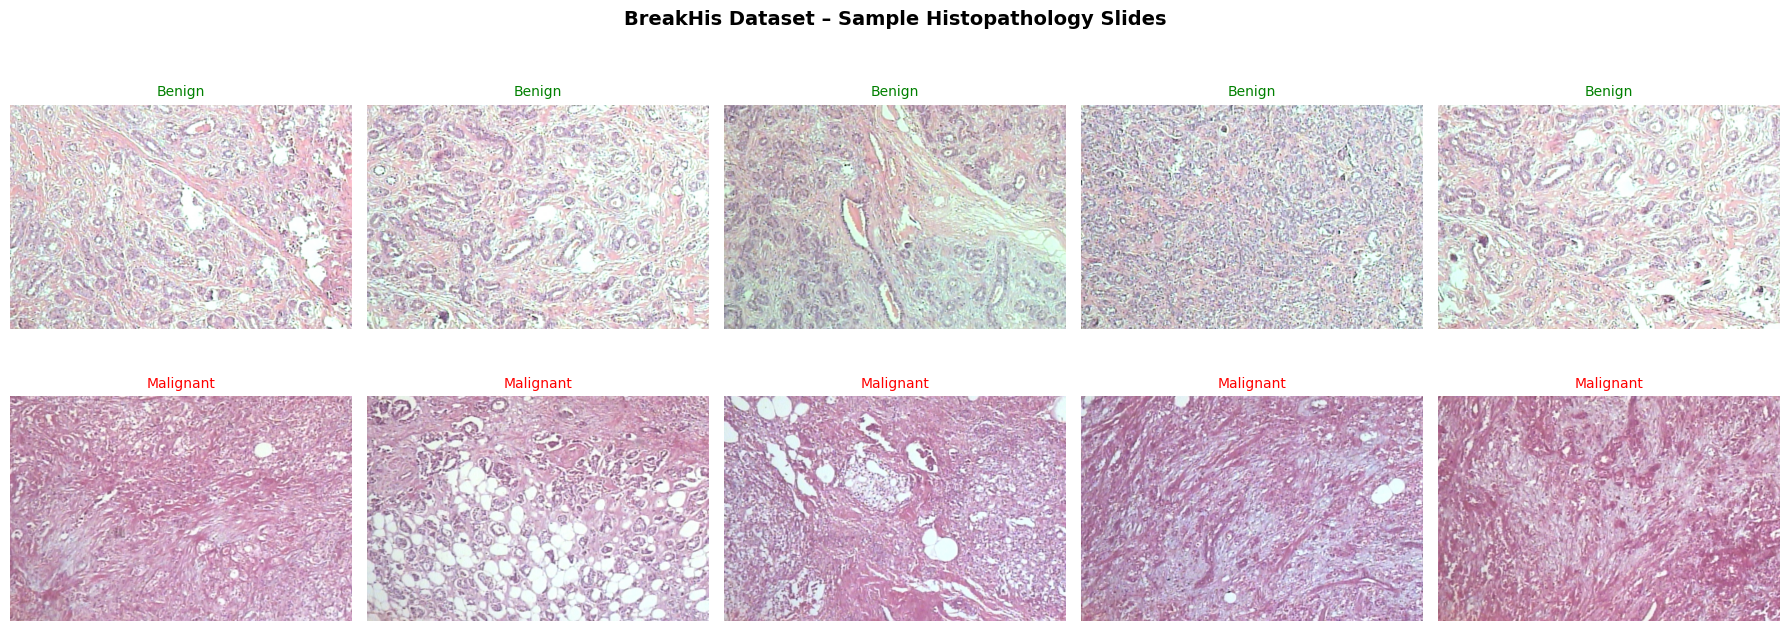

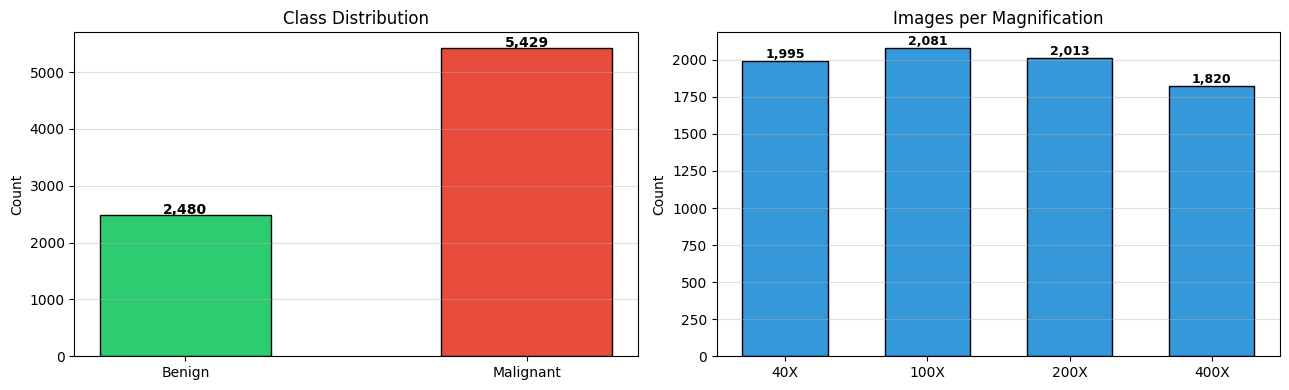

In [4]:
import os, pathlib, collections
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ── Collect image paths & labels ─────────────────────────────────────
# BreakHis structure:  breast/benign/SOB/<subtype>/<case>/<MAG>X/*.png
#                      breast/malignant/SOB/<subtype>/<case>/<MAG>X/*.png
VALID_EXTS = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'}

BENIGN_SUBTYPES    = {'adenosis', 'fibroadenoma', 'phyllodes_tumor', 'tubular_adenoma'}
MALIGNANT_SUBTYPES = {'ductal_carcinoma', 'lobular_carcinoma',
                      'mucinous_carcinoma', 'papillary_carcinoma'}
MAGNIFICATIONS     = {'40X', '100X', '200X', '400X'}

all_paths, all_labels = [], []
subtype_counts = collections.Counter()
mag_counts     = collections.Counter()

for root, dirs, files in os.walk(DRIVE_DATASET_PATH):
    # Determine label from the folder path
    norm = root.replace('\\', '/')
    if '/benign/' in norm:
        label = 0
    elif '/malignant/' in norm:
        label = 1
    else:
        continue  # not inside breast/benign or breast/malignant

    # Determine magnification from the immediate parent folder name (40X, 100X, …)
    mag = os.path.basename(root)   # e.g. "40X"

    for fname in files:
        if pathlib.Path(fname).suffix.lower() not in VALID_EXTS:
            continue

        fpath = os.path.join(root, fname)
        all_paths.append(fpath)
        all_labels.append(label)

        # Subtype is 3 levels above the image file:
        #   breast/<class>/SOB/<subtype>/<case>/<MAG>X/<file>
        parts = norm.split('/')
        for p in parts:
            if p in BENIGN_SUBTYPES or p in MALIGNANT_SUBTYPES:
                subtype_counts[p] += 1
                break

        if mag in MAGNIFICATIONS:
            mag_counts[mag] += 1

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels, dtype=np.int32)

n_benign    = int(np.sum(all_labels == 0))
n_malignant = int(np.sum(all_labels == 1))

print(f'Total images  : {len(all_paths):,}')
print(f'  Benign      : {n_benign:,}')
print(f'  Malignant   : {n_malignant:,}')
print()
print('Per magnification:')
for mag in ['40X', '100X', '200X', '400X']:
    print(f'  {mag:>5} :  {mag_counts[mag]:,}')
print()
print('Per subtype:')
for st, cnt in sorted(subtype_counts.items(), key=lambda x: -x[1]):
    tag = 'B' if st in BENIGN_SUBTYPES else 'M'
    print(f'  [{tag}] {st:<25} : {cnt:,}')

if len(all_paths) == 0:
    raise RuntimeError(
        '❌  No images found! Check that DRIVE_DATASET_ROOT points to the '
        'outer BreaKHis_v1 folder on your Drive.'
    )

# ── Sample images (5 benign + 5 malignant) ───────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for row, label_val, label_name, color in [
    (0, 0, 'Benign',    'green'),
    (1, 1, 'Malignant', 'red')
]:
    idxs = np.where(all_labels == label_val)[0][:5]
    for col, idx in enumerate(idxs):
        img = mpimg.imread(all_paths[idx])
        axes[row][col].imshow(img)
        axes[row][col].set_title(label_name, fontsize=10, color=color)
        axes[row][col].axis('off')
plt.suptitle('BreakHis Dataset – Sample Histopathology Slides',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Class balance bar chart ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(['Benign', 'Malignant'], [n_benign, n_malignant],
            color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
for rect, val in zip(axes[0].patches, [n_benign, n_malignant]):
    axes[0].text(rect.get_x() + rect.get_width()/2, rect.get_height() + 20,
                 f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.4)

mag_labels = ['40X', '100X', '200X', '400X']
mag_vals   = [mag_counts[m] for m in mag_labels]
axes[1].bar(mag_labels, mag_vals, color='#3498db', edgecolor='black', width=0.6)
for rect, val in zip(axes[1].patches, mag_vals):
    axes[1].text(rect.get_x() + rect.get_width()/2, rect.get_height() + 20,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=9)
axes[1].set_title('Images per Magnification')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()


## 5 · Configuration & Data Pipeline

In [5]:
# ── Hyper-parameters ─────────────────────────────────────────────────
IMG_SIZE    = 224          # EfficientNetB0 expects 224×224
BATCH_SIZE  = 32
EPOCHS_P1   = 20           # Phase 1: frozen base
EPOCHS_P2   = 15           # Phase 2: fine-tune top layers
LR_P1       = 1e-3
LR_P2       = 1e-5
SEED        = 42

# ── Train / Val / Test split ─────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    all_paths, all_labels, test_size=0.10, stratify=all_labels, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.12, stratify=y_temp, random_state=SEED)

print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')

Train: 6,263  |  Val: 855  |  Test: 791


In [6]:
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

def decode_and_resize(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    # EfficientNetB0 expects [0,255] — preprocessing is built into the model
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.random_saturation(img, 0.85, 1.15)
    # Random 90° rotation
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img, label

def make_dataset(paths, labels, augment_data=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED)
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, augment_data=True, shuffle=True)
val_ds   = make_dataset(X_val,   y_val)
test_ds  = make_dataset(X_test,  y_test)

print('Datasets ready.')
print(f'Train batches: {len(train_ds)}  |  Val batches: {len(val_ds)}')

Datasets ready.
Train batches: 196  |  Val batches: 27


## 6 · Phase 1 — Train CNN Classifier (Frozen Base)

In [7]:
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

def build_feature_extractor(trainable_base=False):
    """Matches app/ml/model.py — outputs 256-D feature vector."""
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = trainable_base

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', name='feature_dense')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    features = layers.Dense(256, activation='relu', name='feature_out')(x)
    return Model(inputs, features, name='cnn_feature_extractor')

def build_classifier(trainable_base=False):
    feat_model = build_feature_extractor(trainable_base)
    inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    feats   = feat_model(inputs)
    x       = layers.Dropout(0.3)(feats)
    outputs = layers.Dense(1, activation='sigmoid', name='classifier_head')(x)
    return Model(inputs, outputs, name='breast_cnn'), feat_model

# Build Phase 1 model
model_p1, feat_model = build_classifier(trainable_base=False)
model_p1.summary(line_length=90)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "breast_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)            │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ cnn_feature_extractor (Functional)    │ (None, 256)                  │       4,838,819 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                   │ (None, 256)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ classifier_head (Dense)               │ (None, 1)                    │             257 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 4,839,076 (18.46 MB)

 Trainable params: 788,481 (3.01 MB)

 Non-trainable params: 4,050,595 (15.45 MB)

In [8]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight
unique_cls = np.unique(y_train)
cw = compute_class_weight('balanced', classes=unique_cls, y=y_train)
class_weight = dict(zip(unique_cls, cw))
print('Class weights:', class_weight)

model_p1.compile(
    optimizer=Adam(LR_P1),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks_p1 = [
    EarlyStopping(monitor='val_auc', patience=6, mode='max',
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3,
                      min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/best_p1.keras', monitor='val_auc',
                    mode='max', save_best_only=True, verbose=0)
]

print('\n── Phase 1 Training (frozen EfficientNetB0) ──')
history_p1 = model_p1.fit(
    train_ds,
    epochs=EPOCHS_P1,
    validation_data=val_ds,
    callbacks=callbacks_p1,
    class_weight=class_weight,
    verbose=1
)

Class weights: {np.int32(0): np.float64(1.594450101832994), np.int32(1): np.float64(0.7284252151663178)}

── Phase 1 Training (frozen EfficientNetB0) ──
Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 162s 560ms/step - accuracy: 0.8159 - auc: 0.8939 - loss: 0.4537 - precision: 0.9044 - recall: 0.8183 - val_accuracy: 0.8959 - val_auc: 0.9556 - val_loss: 0.2599 - val_precision: 0.8978 - val_recall: 0.9574 - learning_rate: 0.0010
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 68s 341ms/step - accuracy: 0.8612 - auc: 0.9380 - loss: 0.3313 - precision: 0.9337 - recall: 0.8588 - val_accuracy: 0.9193 - val_auc: 0.9744 - val_loss: 0.1996 - val_precision: 0.9151 - val_recall: 0.9727 - learning_rate: 0.0010
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 78s 328ms/step - accuracy: 0.8908 - auc: 0.9570 - loss: 0.2679 - precision: 0.9486 - recall: 0.8890 - val_accuracy: 0.9275 - val_auc: 0.9798 - val_loss: 0.1953 - val_precision: 0.9713 - val_recall: 0.9216 - learning_rate: 0.0010
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━

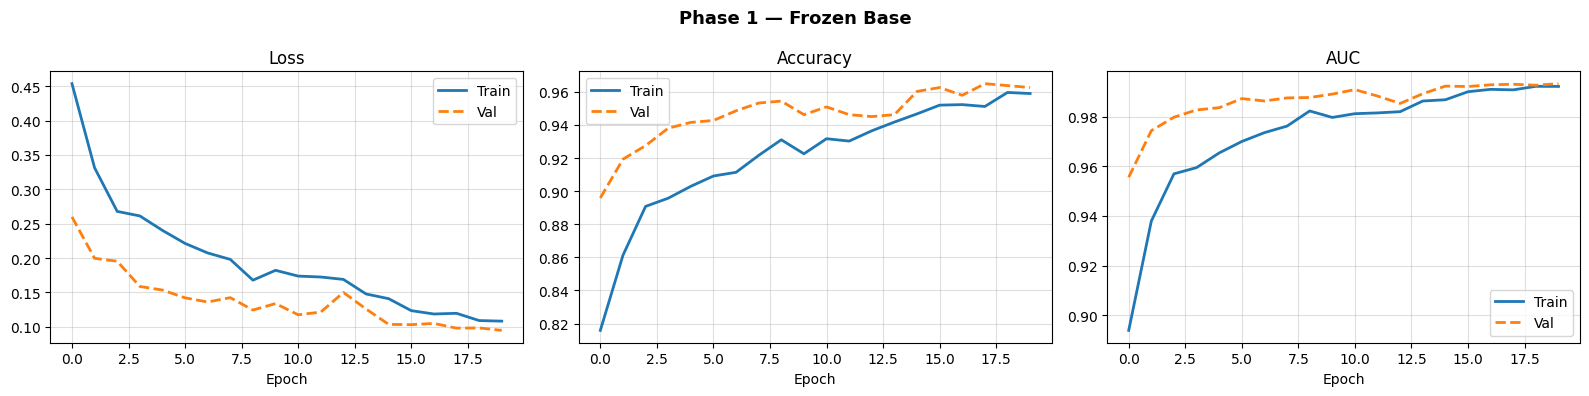

In [9]:
def plot_history(history, title='Training History'):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, metric, label in [
        (axes[0], 'loss',     'Loss'),
        (axes[1], 'accuracy', 'Accuracy'),
        (axes[2], 'auc',      'AUC')
    ]:
        ax.plot(history.history[metric],     label='Train', linewidth=2)
        ax.plot(history.history[f'val_{metric}'], label='Val', linewidth=2, linestyle='--')
        ax.set_title(label)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.4)
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(history_p1, 'Phase 1 — Frozen Base')

## 7 · Phase 2 — Fine-Tune Top Layers

Trainable layers in base: 30 / 238

── Phase 2 Training (fine-tune top 30 layers) ──
Epoch 1/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 128s 490ms/step - accuracy: 0.8255 - auc: 0.9023 - loss: 0.5303 - precision: 0.9096 - recall: 0.8281 - val_accuracy: 0.8994 - val_auc: 0.9639 - val_loss: 0.2800 - val_precision: 0.9210 - val_recall: 0.9336 - learning_rate: 1.0000e-05
Epoch 2/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 65s 330ms/step - accuracy: 0.8603 - auc: 0.9341 - loss: 0.3882 - precision: 0.9379 - recall: 0.8530 - val_accuracy: 0.8912 - val_auc: 0.9617 - val_loss: 0.2815 - val_precision: 0.9259 - val_recall: 0.9148 - learning_rate: 1.0000e-05
Epoch 3/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 81s 325ms/step - accuracy: 0.8751 - auc: 0.9440 - loss: 0.3516 - precision: 0.9458 - recall: 0.8679 - val_accuracy: 0.9053 - val_auc: 0.9651 - val_loss: 0.2608 - val_precision: 0.9423 - val_recall: 0.9182 - learning_rate: 1.0000e-05
Epoch 4/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 64s 325ms/step - accuracy: 0.8825 - auc: 0.9532 - loss:

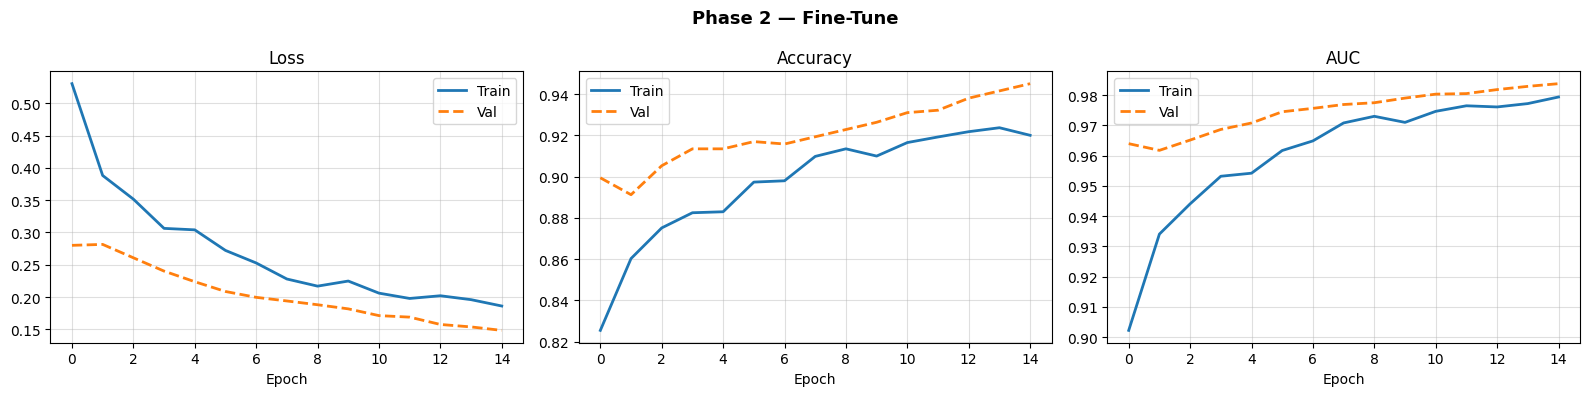

In [10]:
# Unfreeze the top 30 layers of EfficientNetB0
base_layer = model_p1.layers[1]  # the EfficientNetB0 sub-model inside feat_model
# Walk into feat_model → EfficientNetB0
for layer in feat_model.layers:
    if 'efficientnet' in layer.name.lower():
        base_layer = layer
        break

base_layer.trainable = True
# Freeze all but the last 30 layers
for layer in base_layer.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_layer.layers if l.trainable)
print(f'Trainable layers in base: {trainable_count} / {len(base_layer.layers)}')

model_p1.compile(
    optimizer=Adam(LR_P2),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks_p2 = [
    EarlyStopping(monitor='val_auc', patience=7, mode='max',
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3,
                      min_lr=1e-8, verbose=1),
    ModelCheckpoint('/content/best_p2.keras', monitor='val_auc',
                    mode='max', save_best_only=True, verbose=0)
]

print('\n── Phase 2 Training (fine-tune top 30 layers) ──')
history_p2 = model_p1.fit(
    train_ds,
    epochs=EPOCHS_P2,
    validation_data=val_ds,
    callbacks=callbacks_p2,
    class_weight=class_weight,
    verbose=1
)

plot_history(history_p2, 'Phase 2 — Fine-Tune')

## 8 · Phase 3 — Extract Features → Train SVM

In [11]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

print('Extracting CNN features…')

def extract_features(dataset, feat_extractor):
    """Run the feature extractor (no classifier head) over a dataset."""
    # Re-build a model that only goes up to feature_out
    feats, lbls = [], []
    for imgs, labels in dataset:
        f = feat_extractor(imgs, training=False)
        feats.append(f.numpy())
        lbls.append(labels.numpy())
    return np.concatenate(feats, axis=0), np.concatenate(lbls, axis=0)

# feat_model maps image → 256-D vector
# Use training=False (BatchNorm in inference mode)
X_train_feat, y_train_svm = extract_features(train_ds, feat_model)
X_val_feat,   y_val_svm   = extract_features(val_ds,   feat_model)
X_test_feat,  y_test_svm  = extract_features(test_ds,  feat_model)

print(f'Feature shapes — Train: {X_train_feat.shape} | Val: {X_val_feat.shape} | Test: {X_test_feat.shape}')

Extracting CNN features…
Feature shapes — Train: (6263, 256) | Val: (855, 256) | Test: (791, 256)


In [12]:
from sklearn.model_selection import GridSearchCV

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled   = scaler.transform(X_val_feat)
X_test_scaled  = scaler.transform(X_test_feat)

# ── Grid search for best SVM hyper-parameters ────────────────────────
# Using a small grid to keep colab runtime reasonable;
# extend param_grid if you have more time / GPU RAM.
param_grid = {
    'C':     [1, 5, 10],
    'gamma': ['scale', 0.01]
}

print('Running GridSearchCV on SVM (this may take a few minutes)…')
svm_gs = GridSearchCV(
    SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=SEED),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)
svm_gs.fit(X_train_scaled, y_train_svm)

print('Best params:', svm_gs.best_params_)
print('Best CV AUC:', round(svm_gs.best_score_, 4))

svm = svm_gs.best_estimator_

Running GridSearchCV on SVM (this may take a few minutes)…
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'C': 1, 'gamma': 'scale'}
Best CV AUC: 0.9938


## 9 · Evaluation (Test Set)

  Test Accuracy  : 94.44%
  Test AUC       : 0.9771

              precision    recall  f1-score   support

      Benign       0.90      0.92      0.91       248
   Malignant       0.96      0.96      0.96       543

    accuracy                           0.94       791
   macro avg       0.93      0.94      0.94       791
weighted avg       0.94      0.94      0.94       791



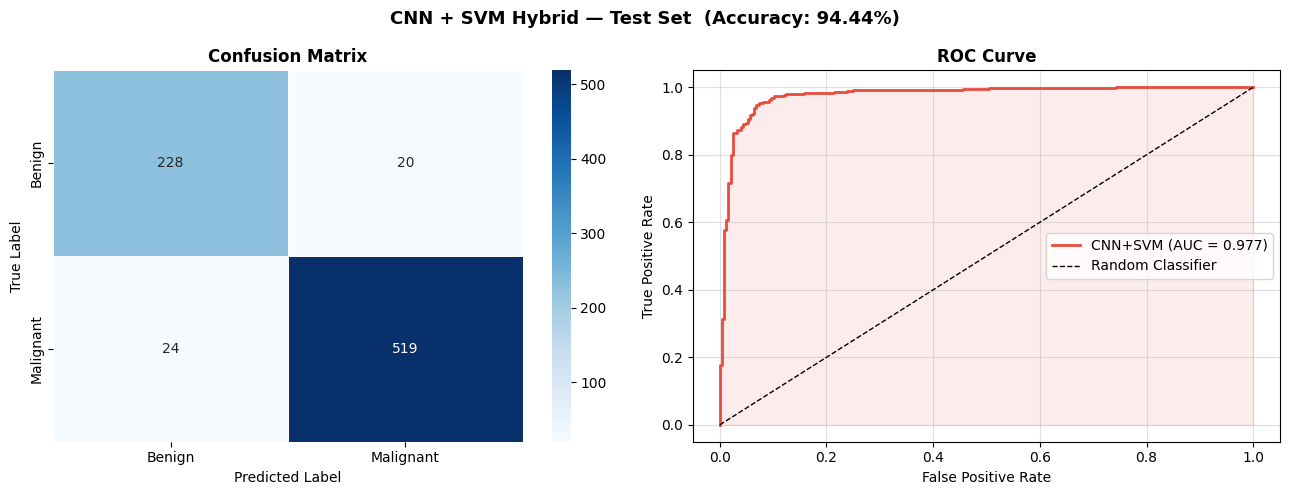


✅ Target accuracy (≥90%) ACHIEVED!


In [13]:
from sklearn.metrics import (classification_report, accuracy_score,
                              roc_auc_score, confusion_matrix, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred      = svm.predict(X_test_scaled)
y_pred_prob = svm.predict_proba(X_test_scaled)[:, 1]

acc  = accuracy_score(y_test_svm, y_pred)
auc  = roc_auc_score(y_test_svm, y_pred_prob)

print('=' * 50)
print(f'  Test Accuracy  : {acc*100:.2f}%')
print(f'  Test AUC       : {auc:.4f}')
print('=' * 50)
print()
print(classification_report(y_test_svm, y_pred,
                             target_names=['Benign', 'Malignant']))

# ── Confusion Matrix ─────────────────────────────────────────────────
cm = confusion_matrix(y_test_svm, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'],
            ax=axes[0], linewidths=.5)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ── ROC Curve ────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test_svm, y_pred_prob)
axes[1].plot(fpr, tpr, lw=2, color='#e74c3c',
             label=f'CNN+SVM (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle(f'CNN + SVM Hybrid — Test Set  (Accuracy: {acc*100:.2f}%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

if acc >= 0.90:
    print('\n✅ Target accuracy (≥90%) ACHIEVED!')
else:
    print(f'\n⚠️  Accuracy is {acc*100:.1f}% — consider more epochs or a larger fine-tune window.')

## 10 · Save Models & Copy to Google Drive

In [14]:
import joblib, shutil

CNN_PATH    = os.path.join(LOCAL_MODEL_OUTPUT, 'cnn_feature_extractor.keras')
SVM_PATH    = os.path.join(LOCAL_MODEL_OUTPUT, 'svm_classifier.joblib')
SCALER_PATH = os.path.join(LOCAL_MODEL_OUTPUT, 'feature_scaler.joblib')

# 1. Save the CNN feature extractor (matches Flask app expectation)
feat_model.save(CNN_PATH)
print('Saved:', CNN_PATH)

# 2. Save SVM
joblib.dump(svm, SVM_PATH)
print('Saved:', SVM_PATH)

# 3. Save scaler
joblib.dump(scaler, SCALER_PATH)
print('Saved:', SCALER_PATH)

# 4. Copy everything to Google Drive (so files survive after runtime)
for src in [CNN_PATH, SVM_PATH, SCALER_PATH]:
    dst = os.path.join(DRIVE_MODEL_OUTPUT, os.path.basename(src))
    shutil.copy2(src, dst)
    print(f'Copied to Drive: {dst}')

# 5. Also save a training metadata file
import json
meta = {
    'accuracy':  round(float(acc), 4),
    'auc':       round(float(auc), 4),
    'img_size':  IMG_SIZE,
    'n_train':   int(len(X_train)),
    'n_val':     int(len(X_val)),
    'n_test':    int(len(X_test)),
    'svm_params': svm_gs.best_params_,
    'trained_at': str(tf.timestamp().numpy()),
    'tf_version': tf.__version__
}
meta_path = os.path.join(DRIVE_MODEL_OUTPUT, 'training_metadata.json')
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print('Metadata saved:', meta_path)

print('\n✅ All models saved successfully!')
print('\nNext step:')
print('  Download these 3 files from Google Drive and place them in:')
print('  C:\\breast_cancer_detection\\app\\ml\\saved_models\\')
print('  ├── cnn_feature_extractor.keras')
print('  ├── svm_classifier.joblib')
print('  └── feature_scaler.joblib')

Saved: /content/saved_models/cnn_feature_extractor.keras
Saved: /content/saved_models/svm_classifier.joblib
Saved: /content/saved_models/feature_scaler.joblib
Copied to Drive: /content/drive/MyDrive/BreastGuard_Models/cnn_feature_extractor.keras
Copied to Drive: /content/drive/MyDrive/BreastGuard_Models/svm_classifier.joblib
Copied to Drive: /content/drive/MyDrive/BreastGuard_Models/feature_scaler.joblib
Metadata saved: /content/drive/MyDrive/BreastGuard_Models/training_metadata.json

✅ All models saved successfully!

Next step:
  Download these 3 files from Google Drive and place them in:
  C:\breast_cancer_detection\app\ml\saved_models\
  ├── cnn_feature_extractor.keras
  ├── svm_classifier.joblib
  └── feature_scaler.joblib


## 11 · (Optional) Download Files Directly to Your PC
Run this cell to download the model files straight to your browser's Downloads folder — no need to go through Drive.

In [15]:
from google.colab import files

print('Starting downloads…')
files.download(CNN_PATH)
files.download(SVM_PATH)
files.download(SCALER_PATH)
print('Downloads triggered. Check your browser Downloads folder.')
print()
print('Place the 3 files in:')
print('  C:\\breast_cancer_detection\\app\\ml\\saved_models\\')

Starting downloads…


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads triggered. Check your browser Downloads folder.

Place the 3 files in:
  C:\breast_cancer_detection\app\ml\saved_models\


## 12 · (Optional) Magnification-Specific Training
BreakHis images are captured at 4 magnification levels: **40×, 100×, 200×, 400×**.  
Train on a single magnification for potentially higher accuracy.

In [16]:
# ── Filter by magnification ───────────────────────────────────────────
# BreakHis stores images inside magnification sub-folders named:
#   40X/  100X/  200X/  400X/
# (uppercase X, matching the exact folder structure you have)
#
# Set TARGET_MAG to one of '40', '100', '200', '400'
# Set TARGET_MAG = None  to use ALL magnifications (recommended first run)

TARGET_MAG = None   # '40' | '100' | '200' | '400' | None

if TARGET_MAG:
    # Match the folder name e.g. /40X/ or \40X\
    mag_folder = f'{TARGET_MAG}X'   # e.g. "400X"
    mask = np.array([
        mag_folder == os.path.basename(os.path.dirname(p))
        for p in all_paths
    ])
    filtered_paths  = all_paths[mask]
    filtered_labels = all_labels[mask]
    n_b = int(np.sum(filtered_labels == 0))
    n_m = int(np.sum(filtered_labels == 1))
    print(f'Magnification {TARGET_MAG}X — Total: {len(filtered_paths):,}'
          f'  (Benign: {n_b:,}  |  Malignant: {n_m:,})')
else:
    filtered_paths  = all_paths
    filtered_labels = all_labels
    print(f'Using ALL magnifications — Total: {len(filtered_paths):,} images')

# ── (Optional) Retrain on filtered subset ────────────────────────────
# To train on only this magnification, re-run cells 4→9 using
# filtered_paths / filtered_labels instead of all_paths / all_labels.
# Quick way: uncomment the two lines below and re-run from Cell 4.

# all_paths  = filtered_paths
# all_labels = filtered_labels


Using ALL magnifications — Total: 7,909 images


---
## 📌 Quick Reference — File Paths After Training

| File | Google Drive | Flask project |
|---|---|---|
| `cnn_feature_extractor.keras` | `MyDrive/BreastGuard_Models/` | `app/ml/saved_models/` |
| `svm_classifier.joblib` | `MyDrive/BreastGuard_Models/` | `app/ml/saved_models/` |
| `feature_scaler.joblib` | `MyDrive/BreastGuard_Models/` | `app/ml/saved_models/` |

After copying the files, restart the Flask server:
```
C:\breast_cancer_detection\venv\Scripts\python.exe C:\breast_cancer_detection\run.py
```
The server will automatically detect and load the trained models on startup.